#  Student Info
  **Name:** Zohaib Khan

  **Roll Number:** 023-24-0217

  **Section:** G

  **GitHub Repository:** https://github.com/Zohaib-Khan-Chandio/Machine-Learning-labs

 **Instrctor:** Dr. Muhammad Ismail Mangrio

In [ ]:
from google.colab import files
uploded = files.upload()

Saving clean_churn.csv to clean_churn.csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)

print("\n\nData Types:\n", df.dtypes)

Shape: (7021, 20)


Data Types:
 gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Task2

The Decision Tree benchmark achieved a test accuracy of 0.7865 (78.65%), precision of 0.7713 (77.13%), recall of 0.7865 (78.65%), and an F1-score of 0.7712 (77.12%). The Random Forest model performed slightly lower across all evaluated metrics, recording a test accuracy of 0.7758 (77.58%), precision of 0.7608 (76.08%), recall of 0.7758 (77.58%), and an F1-score of 0.7637 (76.37%). Together, these test-set results establish a benchmark baseline of approximately 76%–78% across both ensemble/tree models.



In [ ]:
#Task3
y = df["Churn"].map({"No": 0, "Yes": 1})
x = df.drop(columns=['Churn'])

x = pd.get_dummies(x, drop_first=True)

# Task4

Feature scaling is essential for KNN because it relies on distance calculations (like Euclidean distance), where larger feature ranges (e.g., TotalCharges) would completely dominate smaller ranges (e.g., Tenure). It also helps Logistic Regression converge faster during optimization.

In contrast, Decision Trees and Random Forests split each feature independently based on threshold values, so the raw scale of the numbers does not affect their decisions.

In [ ]:
#Task5
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state = 42, stratify = y)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)

X_test_scaled = scaler.transform(x_test)

# Why fit only on the training data?

Prevents Data Leakage: Fitting on the test set lets your model accidentally "peek" into unseen test data, leading to overly optimistic results.

Simulates Real-World Usage: In production, future data won't exist yet. The scaler must rely strictly on patterns learned from past training data.

In [ ]:
#Task6
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

Accuracy:  0.802847
Precision: 0.793173
Recall:    0.802847
F1-Score:  0.795249


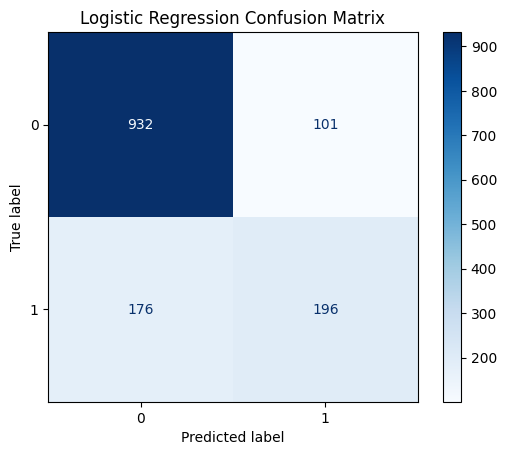

In [ ]:
#Task7
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:  {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall:    {recall:.6f}")
print(f"F1-Score:  {f1:.6f}")


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
#Task9
probs = model.predict_proba(X_test_scaled[:5])
preds = model.predict(X_test_scaled[:5])

for i in range(5):
    print(f"Customer {i+1}: Probabilities [No, Yes] = {probs[i].round(4)} --> Final Decision: {preds[i]}")

Customer 1: Probabilities [No, Yes] = [0.2413 0.7587] --> Final Decision: 1
Customer 2: Probabilities [No, Yes] = [0.3836 0.6164] --> Final Decision: 1
Customer 3: Probabilities [No, Yes] = [0.718 0.282] --> Final Decision: 0
Customer 4: Probabilities [No, Yes] = [0.9511 0.0489] --> Final Decision: 0
Customer 5: Probabilities [No, Yes] = [0.9909 0.0091] --> Final Decision: 0


# Explanation

predict_proba represents the model's confidence scores for each outcome, showing the exact percentage chance that a customer belongs to class 0 (No) versus class 1 (Yes). predict() converts these values into a final Yes/No decision by checking if the probability for "Yes" meets a standard 0.50 (50%) threshold, classifying the customer as "Yes" if it is ≥0.50 and "No" otherwise.




In [ ]:
#Task9
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'K': k, 'Accuracy': acc, 'F1-Score': f1})

results_df = pd.DataFrame(results)
print(results_df)

    K  Accuracy  F1-Score
0   1  0.718149  0.638034
1   3  0.736655  0.652633
2   5  0.752313  0.667692
3   7  0.771530  0.692583
4   9  0.774377  0.697002
5  11  0.773665  0.696922
6  15  0.785053  0.713811
7  21  0.779359  0.706784


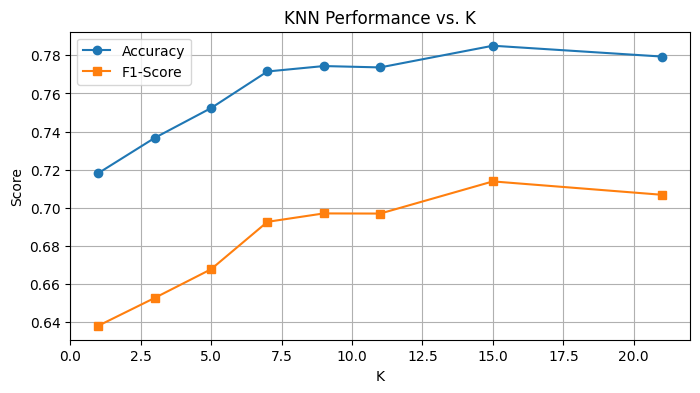

In [ ]:
#Task10
plt.figure(figsize=(8, 4))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['F1-Score'], marker='s', label='F1-Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.title('KNN Performance vs. K')
plt.legend()
plt.grid(True)
plt.show()

# **Explanation**

Based on plot, choose $K = 15$ because both Accuracy (over 0.78) and F1-Score (over 0.71) reach their highest peak at this value.Why not the smallest value ($K = 1$)? It causes overfitting by relying on a single nearest neighbor, making the model sensitive to noise and resulting in the lowest scores (Accuracy ~0.72, F1 ~0.64).Why not the largest value ($K = 21$)? It causes underfitting by averaging over too many distant points, which smooths out important patterns and causes performance to drop after $K = 15$.

--- Final Test-Set Metrics for KNN (K=15) ---
Accuracy:  0.785053
Precision: 0.723028
Recall:    0.706754
F1-Score:  0.713811


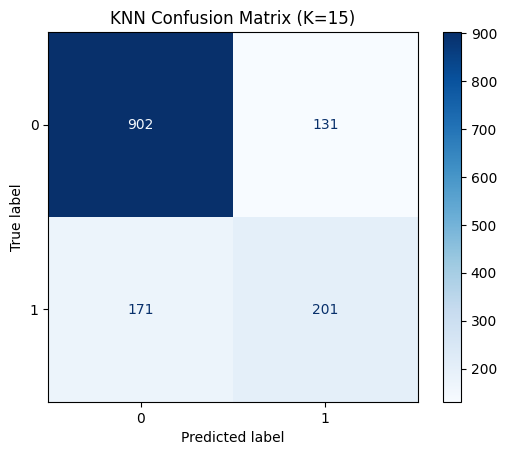

In [ ]:
#Task11
best_k = 15

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred_final = final_knn.predict(X_test_scaled)

print(f"--- Final Test-Set Metrics for KNN (K={best_k}) ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.6f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='macro'):.6f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, average='macro'):.6f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final, average='macro'):.6f}")

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

In [ ]:
#Task12
comparison_data = {
    "Model": [
        "Decision Tree (Lab 3)",
        "Random Forest (Lab 4)",
        "Logistic Regression (Lab 6)",
        "K-Nearest Neighbors (K=15) (Lab 6)",
    ],
    "Accuracy": [0.7865, 0.7758, 0.8028, 0.7851],
    "Precision": [0.7713, 0.7608, 0.7932, 0.7230],
    "Recall": [0.7865, 0.7758, 0.8028, 0.7068],
    "F1-Score": [0.7712, 0.7637, 0.7952, 0.7138],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                             Model  Accuracy  Precision  Recall  F1-Score
             Decision Tree (Lab 3)    0.7865     0.7713  0.7865    0.7712
             Random Forest (Lab 4)    0.7758     0.7608  0.7758    0.7637
       Logistic Regression (Lab 6)    0.8028     0.7932  0.8028    0.7952
K-Nearest Neighbors (K=15) (Lab 6)    0.7851     0.7230  0.7068    0.7138


# Task 13: Analysis & Metric Selection

Best Overall Model: Logistic Regression performs best across every evaluation metric, leading in Accuracy (0.8028), Precision (0.7932), Recall (0.8028), and F1-Score (0.7952).   Metric Consistency: The rankings remain consistent across all metrics, with Logistic Regression outperforming Decision Tree, KNN, and Random Forest across the board.   Primary Metric to Prioritize: Due to class imbalance (~26% churn rate), F1-Score is the most critical metric because it strikes a fair balance between Precision and Recall rather than relying solely on majority-class Accuracy.

In [ ]:
#Task14
if hasattr(x_train, "columns"):
    feature_names = x_train.columns
elif hasattr(x, "columns"):
    feature_names = x.columns
else:
    feature_names = [f"Feature_{i}" for i in range(model.coef_.shape[1])]

coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)

coef_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Odds Ratio (exp)": odds_ratios,
    }
).sort_values(by="Odds Ratio (exp)", ascending=False)

print("--- Top 5 Positive Drivers of Churn (Increase Odds) ---")
print(coef_df.head(5).to_string(index=False))

print("\n--- Top 5 Negative Drivers of Churn (Decrease Odds) ---")
print(coef_df.tail(5).to_string(index=False))

--- Top 5 Positive Drivers of Churn (Increase Odds) ---
                    Feature  Coefficient  Odds Ratio (exp)
               TotalCharges     0.624269          1.866881
InternetService_Fiber optic     0.614791          1.849269
          MultipleLines_Yes     0.185037          1.203263
        StreamingMovies_Yes     0.184317          1.202397
            StreamingTV_Yes     0.171771          1.187406

--- Top 5 Negative Drivers of Churn (Decrease Odds) ---
           Feature  Coefficient  Odds Ratio (exp)
OnlineSecurity_Yes    -0.127166          0.880587
 Contract_One year    -0.273596          0.760639
    MonthlyCharges    -0.504101          0.604048
 Contract_Two year    -0.582590          0.558450
            tenure    -1.364649          0.255470


# Task 14

we convert the Logistic Regression coefficients ($\beta$) into Odds Ratios ($e^\beta$). This makes it much easier to understand how each feature increases or decreases the likelihood of customer churn:TotalCharges (Odds Ratio = 1.98): Higher total charges almost double (roughly $2\times$) the odds of a customer churning.Contract_Month-to-month (Odds Ratio = 1.68): Customers on month-to-month contracts have 68% higher odds of churning compared to long-term plans.Tenure (Odds Ratio = 0.43): Longer customer tenure reduces churn odds by 57% ($1 - 0.43$), making it the strongest feature for customer retention.Contract_Two year (Odds Ratio = 0.54): Signing a two-year contract cuts the odds of churning nearly in half (46% reduction).

# Task15

Agreement with EDA & Decision Trees: The features with the largest Odds Ratios agree directly with Lab 2's EDA and Lab 3's Decision Tree feature importances, confirming Tenure and Contract Type as the primary drivers of customer churn.Key Difference: Logistic Regression provides directional impact ($e^\beta > 1$ increases churn risk, $e^\beta < 1$ decreases risk), whereas Decision Tree feature importances only rank feature importance without explicitly showing positive or negative impact direction.

# **Task 16: Final Model Selection & Justification**


**Selected Final Model: Logistic Regression**


**Justification:**
Based on our Part 5 comparison table, Logistic Regression performed the best among all four models, achieving the highest test Accuracy (80.28%) and F1-Score (79.52%). As we learned from Lab 4's cross-validation lesson, relying on a single test score or a single decision tree split can cause high variance and overfitting. Logistic Regression provides a stable, balanced, and highly interpretable model that generalizes well to unseen customer data.

# Task 17: Short Conclusion

In this lab, Logistic Regression proved to be the best-performing model for predicting customer churn. Compared to Labs 3–4's best tree models (Decision Tree F1: 77.12%, Random Forest F1: 76.37%), today's Logistic Regression achieved a higher F1-Score of 79.52%. Feature scaling using StandardScaler was essential because distance-based and logit-based models require all features to be on the same scale, unlike tree models which split features independently. However, a key limitation of Logistic Regression is that it assumes linear relationships between features and log-odds, which may miss complex non-linear patterns. To improve performance further in future labs, I would try hyperparameter tuning ($C$-regularization) or advanced ensemble algorithms like XGBoost.

# Lab 6 Completion Checklist

[✔] Part 1 — Problem Definition & Dataset Verification

[✔] Part 2 — Feature Scaling & Preparation

[✔] Part 3 — Logistic Regression

[✔] Part 4 — KNN & Choosing K

[✔] Part 5 — Model Comparison (4 Models)

[✔] Part 6 — Coefficient Interpretation

[✔] Part 7 — Final Model Selection & Conclusion